# Serie de tiempo de flujo solar
### María José Soto Castro A01705840


In [256]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler


In [257]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [258]:
flux_path = '/content/drive/MyDrive/solarFlux/solar_flux_table.txt'

In [259]:
df = pd.read_csv(flux_path,
            sep=r"\s+",          # separa por múltiples espacios
            skiprows=[1])     # ignora la línea de guiones)

Se inicia con el formateo de fechas, las columnas que indican tiempo en este dataset son 4:
- Fluxdate: fecha gregoriana de la medición
- Fluxtime: tiempo con reloj atómico o mundial
- fluxjulian: fecha juliana utilizada para interpretar trancisiones de cielo observable
- Fluxcarrington: fecha descrita en no. de rotaciones que ha hecho el sol desde 9 de noviembre del 1853.

In [260]:

# Convertir columnas numéricas
cols = [
    "fluxjulian",
    "fluxcarrington",
    "fluxobsflux",
    "fluxadjflux",
    "fluxursi"
]

df[cols] = df[cols].astype(float)

print(df.dtypes)

fluxdate            int64
fluxtime            int64
fluxjulian        float64
fluxcarrington    float64
fluxobsflux       float64
fluxadjflux       float64
fluxursi          float64
dtype: object


In [261]:
df.head()

,fluxdate,fluxtime,fluxjulian,fluxcarrington,fluxobsflux,fluxadjflux,fluxursi
0,20041028,170000,2453307.229,2022.605,132.7,130.9,117.8
1,20041028,200000,2453307.354,2022.610,135.8,134.0,120.6
2,20041029,200000,2453308.354,2022.646,130.6,128.8,115.9
3,20041029,230000,2453308.479,2022.651,134.2,132.3,119.1
4,20041030,170000,2453309.229,2022.678,147.9,145.8,131.2


In [262]:
#Cambiar formato de fecha en fluxdate

df["fluxdate"] = pd.to_datetime(
    df["fluxdate"].astype(str),
    format="%Y%m%d"
)

print(df["fluxdate"].head())

0   2004-10-28
1   2004-10-28
2   2004-10-29
3   2004-10-29
4   2004-10-30
Name: fluxdate, dtype: datetime64[ns]


In [263]:
#Cambiar formato de tiempo en fluxtime

df["datetime"] = pd.to_datetime(
    df["fluxdate"].dt.strftime("%Y-%m-%d") +
    " " +
    df["fluxtime"].astype(str).str.zfill(6),
    format="%Y-%m-%d %H%M%S"
)

print(df["datetime"].head())

0   2004-10-28 17:00:00
1   2004-10-28 20:00:00
2   2004-10-29 20:00:00
3   2004-10-29 23:00:00
4   2004-10-30 17:00:00
Name: datetime, dtype: datetime64[ns]


In [264]:
df.head()

,fluxdate,fluxtime,fluxjulian,fluxcarrington,fluxobsflux,fluxadjflux,fluxursi,datetime
0,2004-10-28,170000,2453307.229,2022.605,132.7,130.9,117.8,2004-10-28 17:00:00
1,2004-10-28,200000,2453307.354,2022.610,135.8,134.0,120.6,2004-10-28 20:00:00
2,2004-10-29,200000,2453308.354,2022.646,130.6,128.8,115.9,2004-10-29 20:00:00
3,2004-10-29,230000,2453308.479,2022.651,134.2,132.3,119.1,2004-10-29 23:00:00
4,2004-10-30,170000,2453309.229,2022.678,147.9,145.8,131.2,2004-10-30 17:00:00


In [265]:
df.count()

,0
fluxdate,23595
fluxtime,23595
fluxjulian,23595
fluxcarrington,23595
fluxobsflux,23595
fluxadjflux,23595
fluxursi,23595
datetime,23595


Las columnas de fluxobs, fluxadj y fluxursi son estandarizaciones diferentes del mismo dato de flujo solar. Es necesario utilizar estos 3 para utilizarlos en la astronomía, debido a la variación de instrumentos donde se utilizan.


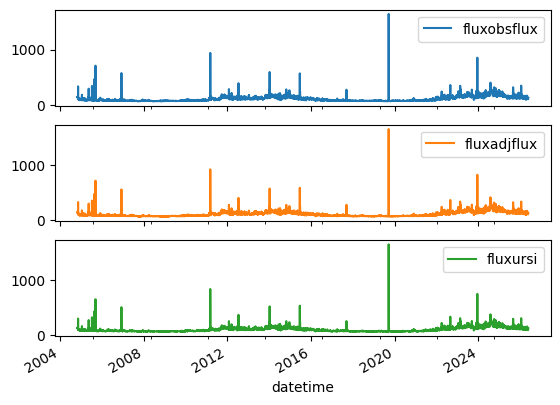

In [266]:
plot_cols = ['fluxobsflux', 'fluxadjflux', 'fluxursi']
plot_features = df[plot_cols]
plot_features.index = df['datetime']
_ = plot_features.plot(subplots=True)




> Se realizan tres mediciones de flujo cada día. Entre marzo y octubre, las mediciones se realizan a las 17:00, 20:00 (mediodía local) y 23:00 UT. Sin embargo, la ubicación en un valle de montaña y una latitud relativamente alta imposibilitan mantener estos horarios durante el resto del año. Por consiguiente, de noviembre a febrero, las mediciones de flujo se realizan a las 18:00, 20:00 y 22:00, para que el Sol esté lo suficientemente alto sobre el horizonte y se pueda realizar una buena medición. (Canada, 2019)



In [267]:
# Crear lags
# 1 día atrás. Cada dia tiene 3 registros
df["lag_day"] = df["fluxadjflux"].shift(3)

# 1 semana atrás
df["lag_week"] = df["fluxadjflux"].shift(21)

# Rotación solar (~27 días)
df["lag_solar_rotation"] = df["fluxadjflux"].shift(81)

# 1 mes atrás
df["lag_month"] = df["fluxadjflux"].shift(90)

# 3 meses atrás
df["lag_3months"] = df["fluxadjflux"].shift(270)

# 1 año atrás
df["lag_year"] = df["fluxadjflux"].shift(1095)

# Eliminar NaNs generados por los lags
df = df.dropna().reset_index(drop=True)

In [268]:
df.head()

,fluxdate,fluxtime,fluxjulian,fluxcarrington,fluxobsflux,fluxadjflux,fluxursi,datetime,lag_day,lag_week,lag_solar_rotation,lag_month,lag_3months,lag_year
0,2005-11-05,200000,2453680.337,2036.284,79.3,77.9,70.1,2005-11-05 20:00:00,76.1,73.1,78.7,79.4,94.9,130.9
1,2005-11-05,220000,2453680.421,2036.288,80.9,79.5,71.6,2005-11-05 22:00:00,77.6,74.3,79.2,79.5,95.6,134.0
2,2005-11-06,180000,2453681.254,2036.318,80.6,79.1,71.2,2005-11-06 18:00:00,76.6,73.9,78.8,78.1,89.3,128.8
3,2005-11-06,200000,2453681.337,2036.321,81.7,80.3,72.3,2005-11-06 20:00:00,77.9,74.5,78.8,78.7,88.9,132.3
4,2005-11-06,220000,2453681.421,2036.324,82.4,80.9,72.8,2005-11-06 22:00:00,79.5,75.7,79.4,79.1,88.9,145.8


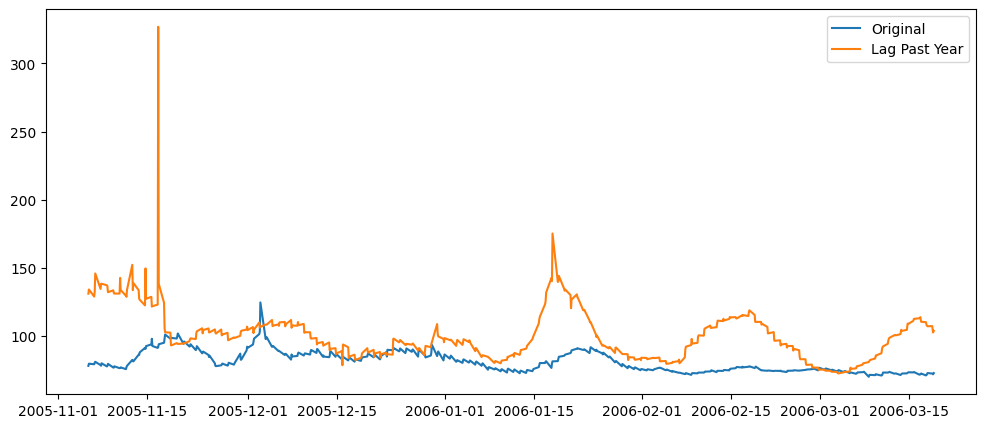

In [269]:
plt.figure(figsize=(12,5))

plt.plot(df["datetime"][:400], df["fluxadjflux"][:400], label="Original")
plt.plot(df["datetime"][:400], df["lag_year"][:400], label="Lag Past Year")

plt.legend()
plt.show()

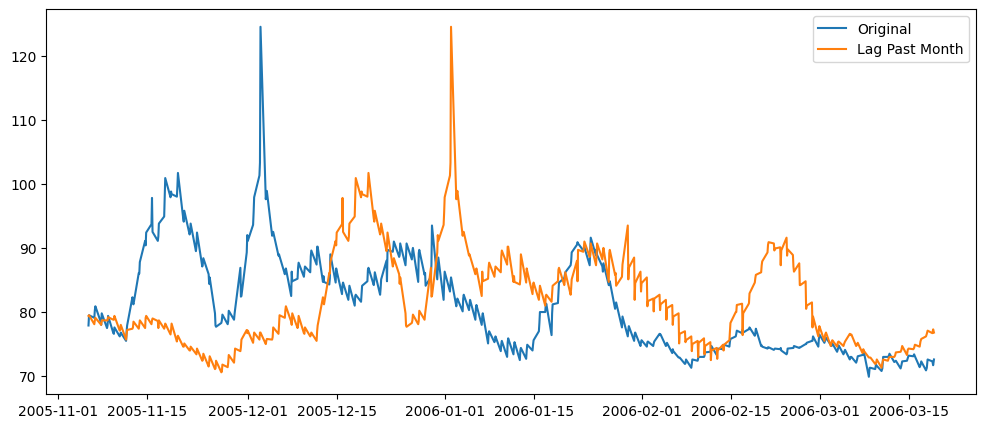

In [270]:

plt.figure(figsize=(12,5))

plt.plot(df["datetime"][:400], df["fluxadjflux"][:400], label="Original")
plt.plot(df["datetime"][:400], df["lag_month"][:400], label="Lag Past Month")

plt.legend()
plt.show()

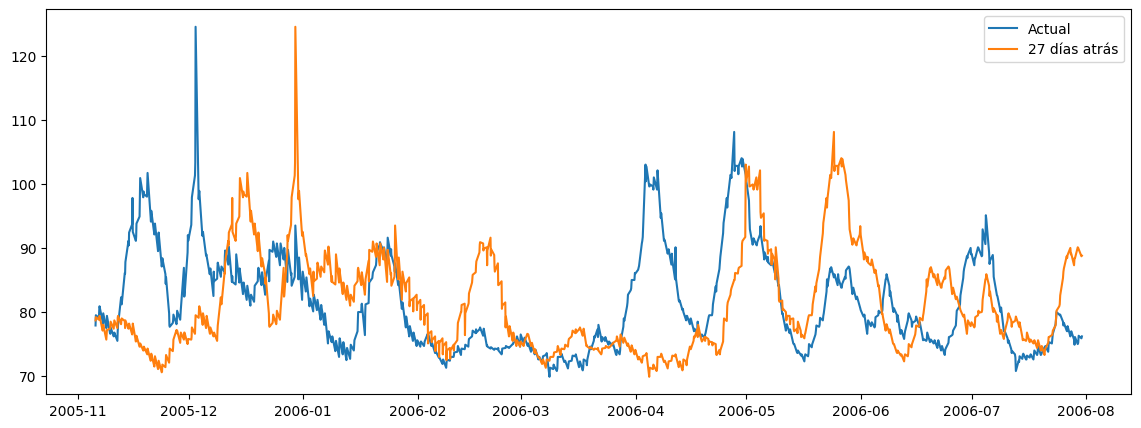

In [271]:
plt.figure(figsize=(14,5))

plt.plot(df["datetime"][:800], df["fluxadjflux"][:800], label="Actual")
plt.plot(df["datetime"][:800], df["lag_solar_rotation"][:800],
         label="27 días atrás")

plt.legend()
plt.show()

# DATA SPLITTING

In [272]:
n = len(df)
train_df = df[0:int(n*0.7)]
val_df = df[int(n*0.7):int(n*0.9)]
test_df = df[int(n*0.9):]

num_features = df.shape[1]

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(15749, 14)
(4501, 14)
(2250, 14)


# Normalisación de datos
Para normalizar los datos, se aplica RobustScaler de sklearn, debido a la fluctuación de datos extrema en flujo solar en vez de utilizar los percentiles de 25% y 75% y la mediana para prevenir perder los datos extremos.

A comparación de min-max o con desviación estandar, los picos en los datos no son erradicados.

In [273]:

features = [
    "fluxobsflux",
    "fluxadjflux",
    "fluxursi",
    "lag_day",
    "lag_week",
    "lag_solar_rotation",
    "lag_month",
    "lag_3months",
    "lag_year"
]
scaler = RobustScaler()

train_df[features] = scaler.fit_transform(train_df[features])

val_df[features] = scaler.transform(val_df[features])

test_df[features] = scaler.transform(test_df[features])

/tmp/ipykernel_2430/1006806919.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df[features] = scaler.fit_transform(train_df[features])
/tmp/ipykernel_2430/1006806919.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_df[features] = scaler.transform(val_df[features])
/tmp/ipykernel_2430/1006806919.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: htt

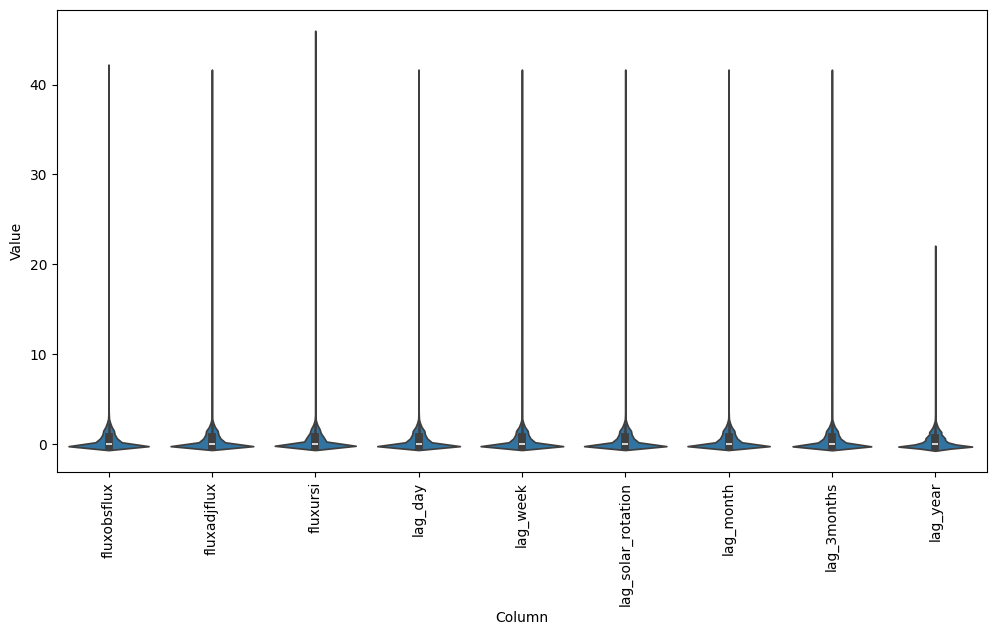

In [274]:
df_plot = train_df[features].melt(
    var_name="Column",
    value_name="Value"
)

plt.figure(figsize=(12,6))

sns.violinplot(
    x="Column",
    y="Value",
    data=df_plot
)

plt.xticks(rotation=90)

plt.show()

Las correlaciones más importantes son entre [fluxobs, fluxadj, fluxursi] y [lag_day, lag_solar_rotation]

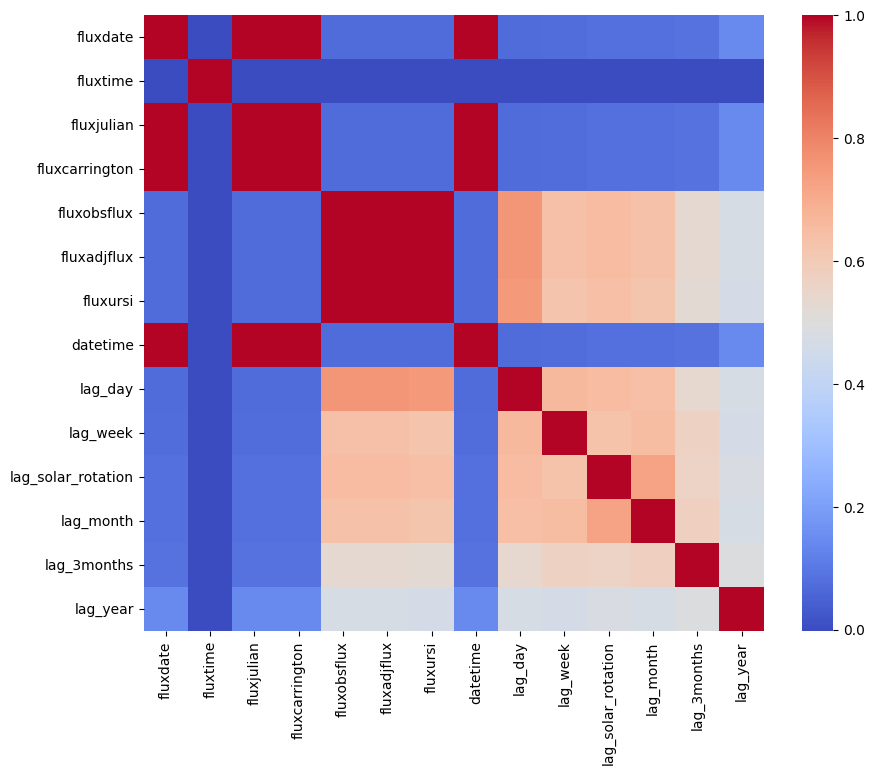

In [275]:
corr = train_df.corr()

plt.figure(figsize=(10,8))

sns.heatmap(corr, cmap="coolwarm")

plt.show()

Los datos no cambian en tendencia, solo en estándar.

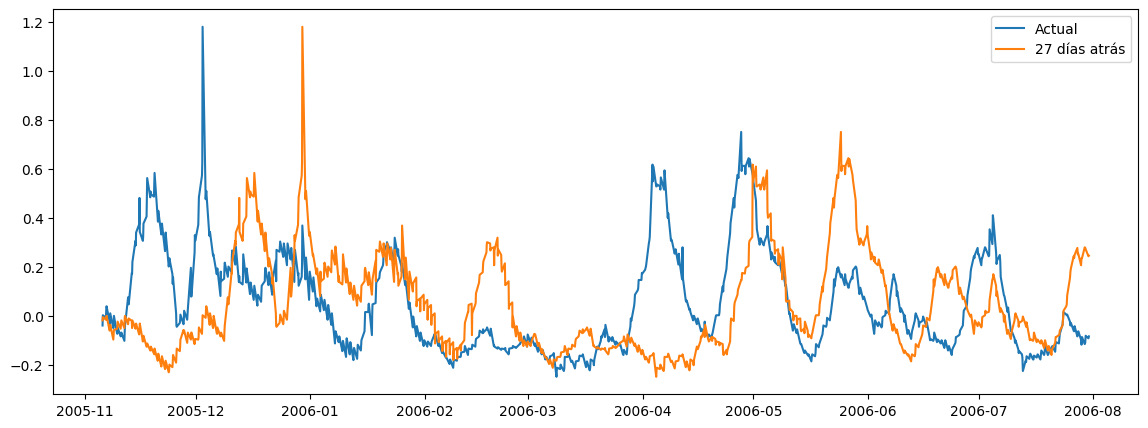

In [276]:
plt.figure(figsize=(14,5))

plt.plot(train_df["datetime"][:800], train_df["fluxadjflux"][:800], label="Actual")
plt.plot(train_df["datetime"][:800], train_df["lag_solar_rotation"][:800],
         label="27 días atrás")

plt.legend()
plt.show()